In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt



Otsu's Threshold Value: 101.0


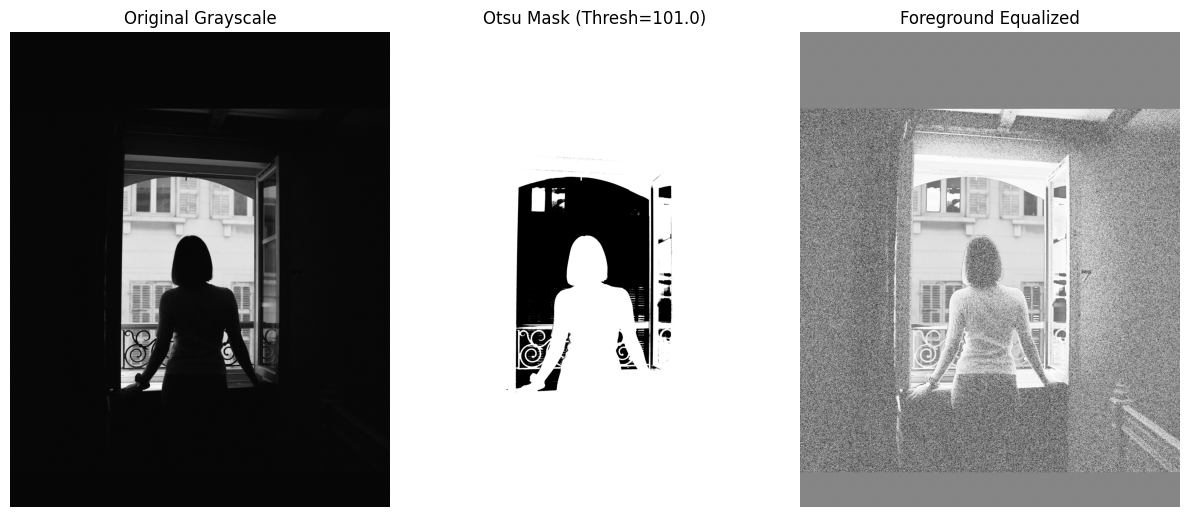

In [9]:
# Load image and convert to Grayscale
img = cv2.imread('a-woman-standing-in-front-of-an-open-door.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Otsu thresholding
thresh_val, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

print(f"Otsu's Threshold Value: {thresh_val}")

# (b) Foreground Histogram Equalization -- extract only the pixels where the mask is white (255)
foreground_pixels = gray[mask == 255]

# Calculate the histogram and CDF of ONLY the foreground pixels
hist, bins = np.histogram(foreground_pixels, 256, [0, 256])
cdf = hist.cumsum()
cdf_m = np.ma.masked_equal(cdf, 0)
cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
cdf = np.ma.filled(cdf_m, 0).astype('uint8')

# Map only the foreground area
gray_corrected = gray.copy()
gray_corrected[mask == 255] = cdf[foreground_pixels]

# Visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title(f"Otsu Mask (Thresh={thresh_val})")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gray_corrected, cmap='gray')
plt.title("Foreground Equalized")
plt.axis('off')

plt.tight_layout()
plt.show()